In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fetching the Dataset

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# ! cp /content/drive/MyDrive/PKG/dataset.zip Dataset.zip

In [4]:
!pip install gdown -q
!gdown 170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U

Downloading...
From (original): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U
From (redirected): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U&confirm=t&uuid=0831b0ec-a353-4655-b589-d6a5e631f210
To: /content/dataset.zip
100% 276M/276M [00:01<00:00, 168MB/s]


In [5]:
! unzip -q dataset.zip

# Importing Dependencies

In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)
import joblib
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# Visualization
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Constants

In [7]:
BATCH_SIZE = 64
IMAGE_SIZE = 144
CHANNELS = 3
EPOCHS = 50
PATH = 'dataset/'

# Importing data into a TensorFlow dataset object

We will use the `image_dataset_from_directory` API to load all images into a TensorFlow dataset. [Link to the documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory)

In [8]:
train_ds = image_dataset_from_directory(
    PATH + '/train',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    PATH + '/test',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 56704 files belonging to 5 classes.
Found 24510 files belonging to 5 classes.


In [9]:
class_names = train_ds.class_names
class_names

['CBFB_MYH11', 'NPM1', 'Normal', 'PML_RARA', 'RUNX1_RUNX1T1']

# Visualizing the first batch of images.

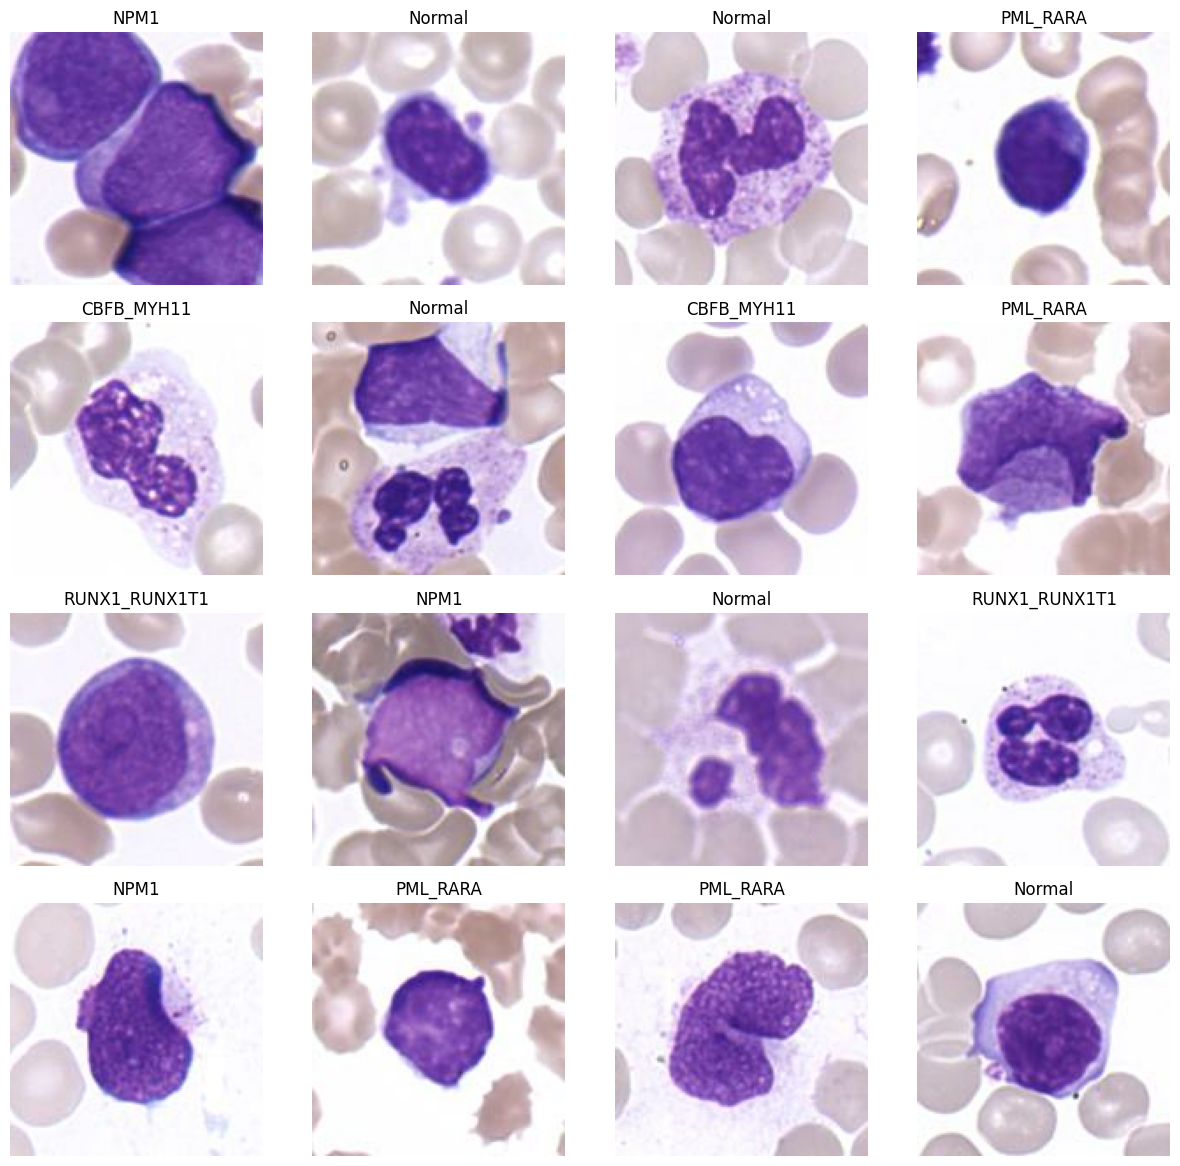

In [10]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


# Spliting Training and Validation Set

In [11]:
TRAIN_SIZE, VALIDATION_SIZE= 0.9, 0.1

In [12]:
train_batch = int(len(train_ds) * TRAIN_SIZE)
train_data = train_ds.take(train_batch)

In [13]:
val_batch = int(len(train_ds) * VALIDATION_SIZE)
validation_data = train_ds.skip(train_batch).take(val_batch)

# Building Model

## Resizing and Normalization Layer

In [14]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

## Data Augmentation

In [15]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2),
  layers.RandomFlip(seed = 42)
])

## Applying Data Augmentation to Train Dataset

In [16]:
train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

## Model Architecture

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

class MLP(layers.Layer):
    def __init__(self, hidden_units, dropout_rate):
        super().__init__()
        self.layers = []
        for units in hidden_units:
            self.layers.append(layers.Dense(units, activation=tf.nn.gelu))
            self.layers.append(layers.Dropout(dropout_rate))

    def call(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class PatchEmbed(layers.Layer):
    def __init__(self, img_size, patch_size, embed_dim):
        super().__init__()
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size)
        self.num_patches = (img_size // patch_size) ** 2

    def call(self, x):
        x = self.proj(x)
        return tf.reshape(x, [-1, self.num_patches, x.shape[-1]])

class WindowAttention(layers.Layer):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.attn_drop = layers.Dropout(attn_drop)
        self.proj = layers.Dense(dim)
        self.proj_drop = layers.Dropout(proj_drop)

    def call(self, x):
        B_, N, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        x = tf.matmul(attn, v)
        x = tf.transpose(x, [0, 2, 1, 3])
        x = tf.reshape(x, [B_, N, C])
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MaxViTBlock(layers.Layer):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0., window_size=7):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = WindowAttention(dim, window_size, num_heads, qkv_bias, attn_drop, drop)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP([mlp_hidden_dim, dim], drop)

    def call(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class WindowPartition(layers.Layer):
    def __init__(self, window_size):
        super().__init__()
        self.window_size = window_size

    def call(self, x):
        B, H, W, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        x = tf.reshape(x, [B, H // self.window_size, self.window_size, W // self.window_size, self.window_size, C])
        windows = tf.transpose(x, [0, 1, 3, 2, 4, 5])
        windows = tf.reshape(windows, [-1, self.window_size * self.window_size, C])
        return windows

class WindowReverse(layers.Layer):
    def __init__(self, window_size, H, W):
        super().__init__()
        self.window_size = window_size
        self.H = H
        self.W = W

    def call(self, windows):
        B = tf.shape(windows)[0] // (self.H * self.W // self.window_size // self.window_size)
        x = tf.reshape(windows, [B, self.H // self.window_size, self.W // self.window_size, self.window_size, self.window_size, -1])
        x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
        x = tf.reshape(x, [B, self.H, self.W, -1])
        return x

def create_maxvit_model(img_size=224, patch_size=16, in_channels=3, num_classes=1000,
                        embed_dim=96, depth=12, num_heads=8, mlp_ratio=4., qkv_bias=True,
                        drop_rate=0., attn_drop_rate=0., window_size=7):
    inputs = Input(shape=(img_size, img_size, in_channels))

    # Patch Embedding
    x = PatchEmbed(img_size, patch_size, embed_dim)(inputs)
    x = layers.Reshape((img_size // patch_size, img_size // patch_size, embed_dim))(x)

    # MaxViT Blocks
    for _ in range(depth):
        # Block-wise self-attention
        x_windows = WindowPartition(window_size)(x)
        x_windows = MaxViTBlock(embed_dim, num_heads, mlp_ratio, qkv_bias, drop_rate, attn_drop_rate, window_size)(x_windows)
        x = WindowReverse(window_size, img_size // patch_size, img_size // patch_size)(x_windows)

        # Global self-attention
        x = layers.Reshape((-1, embed_dim))(x)
        x = MaxViTBlock(embed_dim, num_heads, mlp_ratio, qkv_bias, drop_rate, attn_drop_rate)(x)
        x = layers.Reshape((img_size // patch_size, img_size // patch_size, embed_dim))(x)

    # Final layers
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# Parameters
IMG_SIZE = 144
PATCH_SIZE = 12
IN_CHANNELS = 3
NUM_CLASSES = len(class_names)
EMBED_DIM = 32
DEPTH = 8
NUM_HEADS = 4
MLP_RATIO = 4.
QKV_BIAS = True
DROP_RATE = 0.1
ATTN_DROP_RATE = 0.1
WINDOW_SIZE = 12

model = create_maxvit_model(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    qkv_bias=QKV_BIAS,
    drop_rate=DROP_RATE,
    attn_drop_rate=ATTN_DROP_RATE,
    window_size=WINDOW_SIZE
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    ],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 144, 144, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ patch_embed (PatchEmbed)             │ (None, 144, 32)             │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_partition (WindowPartition)   │ (None, 144, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block (MaxViTBlock)         │ (None, 144, 32)             │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_reverse (WindowReverse)       │ (None, 12, 12, None)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, None, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block_1 (MaxViTBlock)       │ (None, None, 32)            │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_partition_1 (WindowPartition) │ (None, 144, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block_2 (MaxViTBlock)       │ (None, 144, 32)             │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_reverse_1 (WindowReverse)     │ (None, 12, 12, None)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_3 (Reshape)                  │ (None, None, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block_3 (MaxViTBlock)       │ (None, None, 32)            │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_4 (Reshape)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_partition_2 (WindowPartition) │ (None, 144, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block_4 (MaxViTBlock)       │ (None, 144, 32)             │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ window_reverse_2 (WindowReverse)     │ (None, 12, 12, None)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, None, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_vi_t_block_5 (MaxViTBlock)       │ (None, None, 32)            │          12,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_6 (Reshape)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 217,349 (849.02 KB)

 Trainable params: 217,349 (849.02 KB)

 Non-trainable params: 0 (0.00 B)

Creating a checkpoint to save the model with the best score.

In [ ]:
callback = [
    tf.keras.callbacks.ModelCheckpoint(filepath='model.keras', monitor="val_accuracy")
]

## Training

In [ ]:
history = model.fit(
    train_data,
    batch_size = BATCH_SIZE,
    validation_data = validation_data,
    verbose = 1,
    epochs = EPOCHS,
    # epochs = 1,
    callbacks = callback
)

Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 212s 266ms/step - accuracy: 0.2267 - loss: 1.6318 - val_accuracy: 0.2706 - val_loss: 1.5771
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 200s 251ms/step - accuracy: 0.2639 - loss: 1.5930 - val_accuracy: 0.3086 - val_loss: 1.5566
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 197s 246ms/step - accuracy: 0.2990 - loss: 1.5659 - val_accuracy: 0.3189 - val_loss: 1.5401
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 205s 251ms/step - accuracy: 0.3103 - loss: 1.5522 - val_accuracy: 0.3340 - val_loss: 1.5243
Epoch 5/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 209s 263ms/step - accuracy: 0.3249 - loss: 1.5330 - val_accuracy: 0.3333 - val_loss: 1.5099
Epoch 6/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 210s 264ms/step - accuracy: 0.3373 - loss: 1.5076 - val_accuracy: 0.3597 - val_loss: 1.4666
Epoch 7/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 201s 252ms/step - accuracy: 0.3540 - loss: 1.4687 - val_accuracy: 0.3782 - val_loss: 1.4203
Epoch 8/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 213s 266ms/step - accuracy: 0.3678 -

## Loading Model

In [ ]:
model = load_model('model.keras')

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 144, 144, 3], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_1'}, 'registered_name': None, 'name': 'input_layer_1', 'inbound_nodes': []}, {'module': None, 'class_name': 'PatchEmbed', 'config': {'img_size': 144, 'patch_size': 12, 'embed_dim': 32, 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}}, 'registered_name': 'PatchEmbed', 'build_config': {'input_shape': [None, 144, 144, 3]}, 'name': 'patch

# Evaluation

### Predict

In [ ]:
all_predictions = []
all_labels = []
for images, labels in tqdm(test_ds):
    predictions = model.predict(images, verbose = 0)
    predicted_classes = np.argmax(predictions, axis=1)
    all_predictions.extend(predicted_classes)
    all_labels.extend(labels.numpy())

100%|██████████| 383/383 [01:21<00:00,  4.67it/s]


### Metrices

In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.5318645450836393
F1 Score:  0.5293749967890345
Recall:  0.5318645450836393
Precision:  0.5284876827314086


### Confusion Matrix

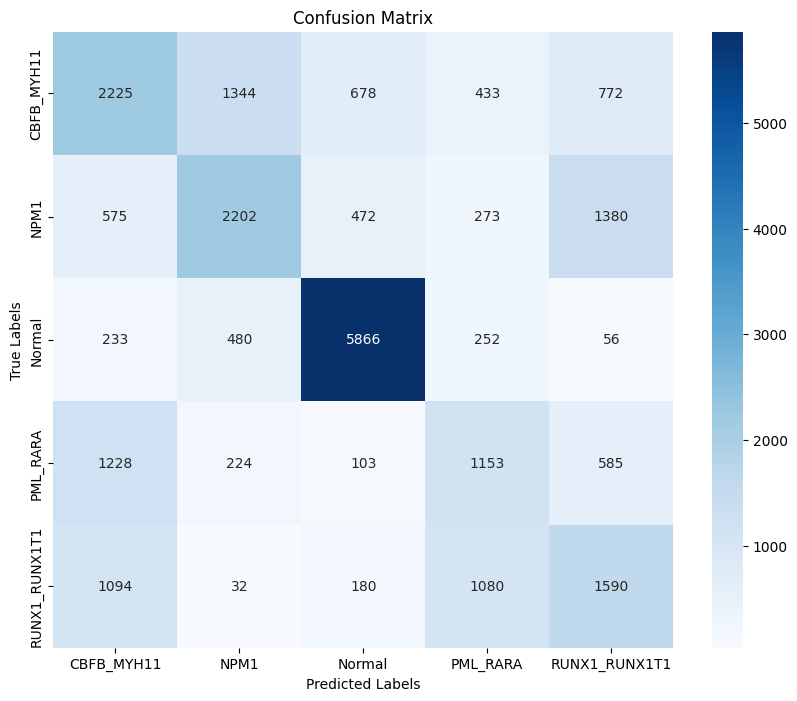

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', dpi = 300)
plt.show()


## Accuracy and Loss Curves

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

from scipy.ndimage import gaussian_filter1d

sacc = gaussian_filter1d(acc, sigma=2)
sval_acc = gaussian_filter1d(val_acc, sigma=2)

sloss = gaussian_filter1d(loss, sigma=2)
sval_loss = gaussian_filter1d(val_loss, sigma=2)

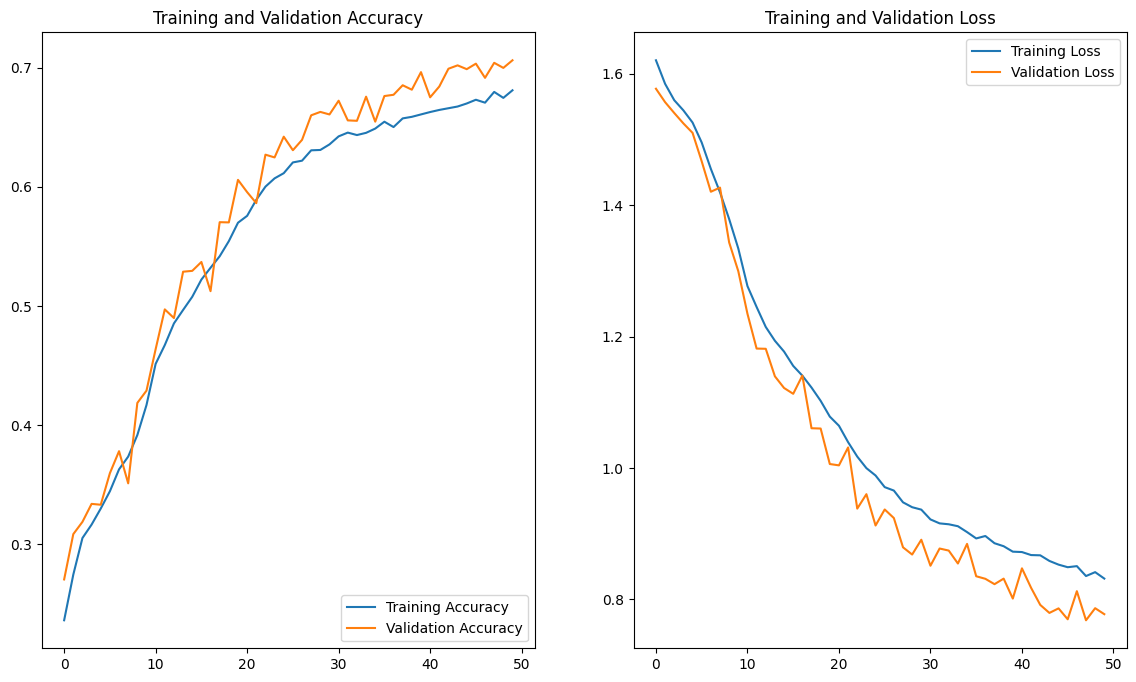

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('curves.png', dpi = 300)
plt.show()

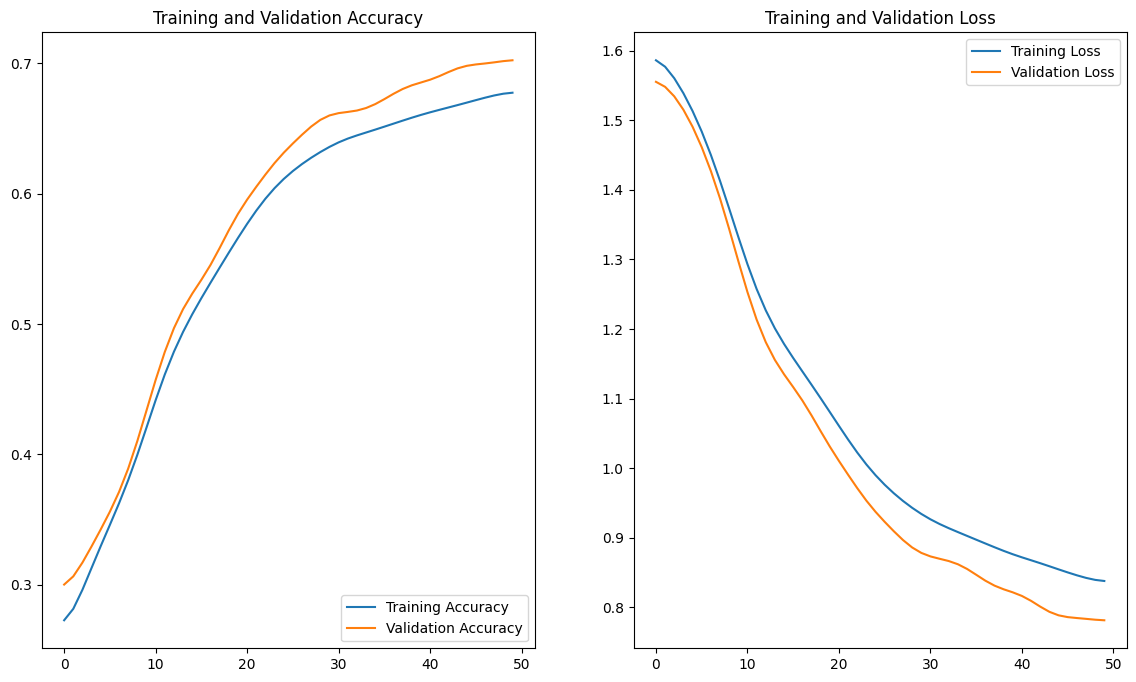

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), sacc, label='Training Accuracy')
plt.plot(range(EPOCHS), sval_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), sloss, label='Training Loss')
plt.plot(range(EPOCHS), sval_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('smoothed curves.png', dpi = 300)
plt.show()

# Inference



## Inference Function

In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose = 0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

## Running Inference

<Figure size 640x480 with 0 Axes>

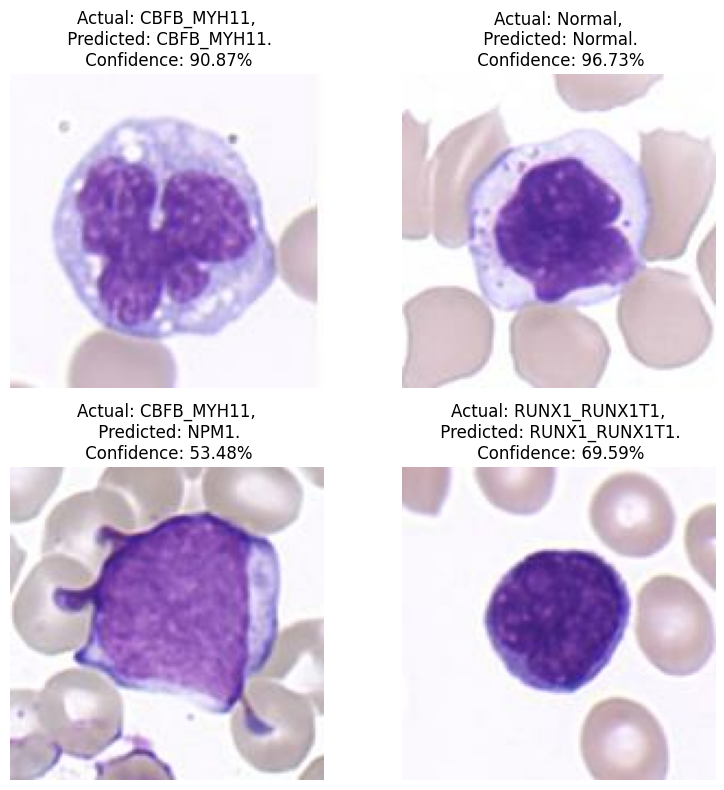

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in test_ds.take(6):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
            ax.axis("off")
plt.tight_layout()
plt.show()


# Optional

In [ ]:
!cp model.keras /content/drive/MyDrive/PKG/models/maxvit.keras